# Álgebra Lineal con SymPy & Grafos con NetworkX

**Temas tratados:**
1. Multiplicación de vectores con matrices
2. Potencias de matrices
3. Solución de sistemas de ecuaciones lineales
4. Valores y vectores propios (eigenvalores / eigenvectores)
5. Diagramas de transición con NetworkX


## 0. Importaciones

In [29]:
from sympy import (
    Matrix, symbols, sqrt, Rational, eye, zeros,
    pretty, init_printing, latex
)
from sympy import pprint
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

init_printing(use_unicode=True)
print("Librerías cargadas correctamente")


Librerías cargadas correctamente


---
## 1. Multiplicación de Vectores con Matrices

En SymPy, los vectores son simplemente matrices columna (shape *n×1*)
o matrices fila (shape *1×n*).

### 1.1 Transformación lineal: $\mathbf{y} = A\mathbf{x}$


In [30]:
# Definimos una matriz de transformación A
A = Matrix([
    [2, -1,  0],
    [1,  3, -2],
    [0,  1,  4]
])

# Vector columna x
x = Matrix([1, -1, 2])

# Transformación Ax
y = A * x

print("Matriz A:")
pprint(A)
print("\nVector x:")
pprint(x)
print("\n y = A·x:")
pprint(y)


Matriz A:
⎡2  -1  0 ⎤
⎢         ⎥
⎢1  3   -2⎥
⎢         ⎥
⎣0  1   4 ⎦

Vector x:
⎡1 ⎤
⎢  ⎥
⎢-1⎥
⎢  ⎥
⎣2 ⎦

 y = A·x:
⎡3 ⎤
⎢  ⎥
⎢-6⎥
⎢  ⎥
⎣7 ⎦


### 1.2 Forma cuadrática: $x^T A x$

Una forma cuadrática genera un escalar a partir de $\mathbf{x}^T A \mathbf{x}$.


In [31]:
# Transpuesta de x
xT = x.T

forma_cuadratica = xT * A * x
print("x^T · A · x =")
pprint(forma_cuadratica)


x^T · A · x =
[23]


### 1.3 Producto interno y norma

SymPy también permite calcular el producto interno $\mathbf{u} \cdot \mathbf{v}$
y la norma $\|\mathbf{v}\|$.


In [32]:
u = Matrix([1, 2, 3])
v = Matrix([4, -1, 2])

# Producto interno (dot product)
dot_uv = u.dot(v)
print(f"u · v = {dot_uv}")

# Norma (sqrt de sympy)
norma_u = u.norm()
print(f"||u|| = {norma_u}")

# Vector unitario
u_hat = u / u.norm()
print("\nVector unitario û:")
pprint(u_hat)


u · v = 8
||u|| = sqrt(14)

Vector unitario û:
⎡ √14 ⎤
⎢ ─── ⎥
⎢ 14  ⎥
⎢     ⎥
⎢ √14 ⎥
⎢ ─── ⎥
⎢  7  ⎥
⎢     ⎥
⎢3⋅√14⎥
⎢─────⎥
⎣ 14  ⎦


---
## 2. Potencias de Matrices

La potencia $A^n$ se calcula directamente con el operador `**`.
Esto es especialmente útil en cadenas de Markov, donde
$\mathbf{p}^{(n)} = A^n \mathbf{p}^{(0)}$.


In [33]:
# Matriz de transición (cadena de Markov simple)
P = Matrix([
    [Rational(1,2), Rational(1,4), Rational(1,4)],
    [Rational(1,3), Rational(1,3), Rational(1,3)],
    [Rational(1,6), Rational(1,2), Rational(1,3)]
])

print("Matriz de transición P:")
pprint(P)

# cada fila suma 1
print("\nSumas por fila:", [sum(P.row(i)) for i in range(3)])


Matriz de transición P:
⎡1/2  1/4  1/4⎤
⎢             ⎥
⎢1/3  1/3  1/3⎥
⎢             ⎥
⎣1/6  1/2  1/3⎦

Sumas por fila: [1, 1, 1]


In [34]:
# Potencias de P
for n in [1, 2, 5, 10]:
    Pn = P**n
    print(f"\nP^{n}:")
    pprint(Pn.evalf(4))


P^1:
⎡ 0.5     0.25    0.25 ⎤
⎢                      ⎥
⎢0.3333  0.3333  0.3333⎥
⎢                      ⎥
⎣0.1667   0.5    0.3333⎦

P^2:
⎡0.375   0.3333  0.2917⎤
⎢                      ⎥
⎢0.3333  0.3611  0.3056⎥
⎢                      ⎥
⎣0.3056  0.375   0.3194⎦

P^5:
⎡0.3394  0.3557  0.3049⎤
⎢                      ⎥
⎢0.3389  0.356   0.3051⎥
⎢                      ⎥
⎣0.3386  0.3562  0.3052⎦

P^10:
⎡0.339  0.3559  0.3051⎤
⎢                     ⎥
⎢0.339  0.3559  0.3051⎥
⎢                     ⎥
⎣0.339  0.3559  0.3051⎦


In [35]:
# Distribución inicial y evolución temporal
p0 = Matrix([1, 0, 0])   # Estado inicial: todo en estado 0

print("Evolución de la distribución de probabilidad:")
print(f"{'n':>4}  {'Estado 0':>12}  {'Estado 1':>12}  {'Estado 2':>12}")
print("-" * 46)
for n in range(8):
    pn = (P**n * p0).T
    vals = [float(pn[i].evalf()) for i in range(3)]
    print(f"{n:>4}  {vals[0]:>12.6f}  {vals[1]:>12.6f}  {vals[2]:>12.6f}")


Evolución de la distribución de probabilidad:
   n      Estado 0      Estado 1      Estado 2
----------------------------------------------
   0      1.000000      0.000000      0.000000
   1      0.500000      0.333333      0.166667
   2      0.375000      0.333333      0.305556
   3      0.347222      0.337963      0.331019
   4      0.340856      0.338735      0.337191
   5      0.339410      0.338927      0.338574
   6      0.339080      0.338970      0.338890
   7      0.339005      0.338980      0.338962


---
## 3. Solución de Sistemas de Ecuaciones Lineales

Dado $A\mathbf{x} = \mathbf{b}$, SymPy ofrece tres enfoques:

| Método | Función |
|---|---|
| Inversa | `A.inv() * b` |
| `solve_linear_system` | `A.solve(b)` |
| Forma escalonada | `A.rref()` |


In [36]:
# Sistema 3×3 determinado
#   2x + y - z  = 8
#  -3x - y + 2z = -11
#  -2x + y + 2z = -3

A3 = Matrix([
    [ 2,  1, -1],
    [-3, -1,  2],
    [-2,  1,  2]
])
b3 = Matrix([8, -11, -3])

# Método 1: usando solve()
sol = A3.solve(b3)
print("Solución por A.solve(b):")
pprint(sol)
print(f"  x={sol[0]}, y={sol[1]}, z={sol[2]}")

# Verificación
print("\nVerificación A·x - b =", (A3*sol - b3).T)


Solución por A.solve(b):
⎡2 ⎤
⎢  ⎥
⎢3 ⎥
⎢  ⎥
⎣-1⎦
  x=2, y=3, z=-1

Verificación A·x - b = Matrix([[0, 0, 0]])


In [37]:
# Sistema subdeterminado (solución paramétrica)
#   x + 2y + 3z = 6
#   2x + 4y + 6z = 12
A_sub = Matrix([
    [1, 2, 3, 6],
    [2, 4, 6, 12]
])

print("Forma escalonada reducida (RREF) del sistema ampliado:")
rref, pivots = A_sub.rref()
pprint(rref)
print(f"Columnas pivote: {pivots}")
print("\nEl sistema tiene infinitas soluciones (rango 1 < 3 incógnitas)")


Forma escalonada reducida (RREF) del sistema ampliado:
⎡1  2  3  6⎤
⎢          ⎥
⎣0  0  0  0⎦
Columnas pivote: (0,)

El sistema tiene infinitas soluciones (rango 1 < 3 incógnitas)


In [38]:
# Sistema sin solución (inconsistente)
A_inc = Matrix([
    [1,  2,  3],
    [2,  4,  6],
    [1,  2,  4]
])
b_inc = Matrix([1, 2, 4])

print("Rango de A  :", A_inc.rank())
print("Rango de [A|b]:", A_inc.col_insert(3, b_inc).rank())
print("\nrango(A) ≠ rango([A|b])  →  Sistema INCOMPATIBLE (sin solución)")


Rango de A  : 2
Rango de [A|b]: 2

rango(A) ≠ rango([A|b])  →  Sistema INCOMPATIBLE (sin solución)


---
## 4. Valores y Vectores Propios (Eigenvalores / Eigenvectores)

Para una matriz $A$, buscamos $\lambda$ y $\mathbf{v} \neq 0$ tales que:

$$A\mathbf{v} = \lambda\mathbf{v}$$

Los eigenvalores se obtienen de $\det(A - \lambda I) = 0$.


In [39]:
B = Matrix([
    [4, 1],
    [2, 3]
])

print("Matriz B:")
pprint(B)

# Polinomio característico
lam = symbols('lambda')
p_car = B.charpoly(lam)
print("\nPolinomio característico p(λ):")
pprint(p_car.as_expr())


Matriz B:
⎡4  1⎤
⎢    ⎥
⎣2  3⎦

Polinomio característico p(λ):
 2           
λ  - 7⋅λ + 10


In [40]:
# Eigenvalores con su multiplicidad algebraica
eigenvals = B.eigenvals()
print("Eigenvalores (valor: multiplicidad):")
for val, mult in eigenvals.items():
    print(f"  λ = {val}  (multiplicidad {mult})")

# Eigenvectores: lista de (eigenvalor, multiplicidad, [vectores])
eigenvects = B.eigenvects()
print("\nEigenvectores:")
for val, mult, vects in eigenvects:
    print(f"  λ = {val}:")
    for v in vects:
        print(f"    v = {v.T}")


Eigenvalores (valor: multiplicidad):
  λ = 5  (multiplicidad 1)
  λ = 2  (multiplicidad 1)

Eigenvectores:
  λ = 2:
    v = Matrix([[-1/2, 1]])
  λ = 5:
    v = Matrix([[1, 1]])


In [41]:
# Diagonalización: B = P D P^{-1}
P_mat, D_mat = B.diagonalize()
print("Matriz de cambio de base P (columnas = eigenvectores):")
pprint(P_mat)
print("\nMatriz diagonal D (eigenvalores):")
pprint(D_mat)
print("\nVerificación P·D·P⁻¹ = B:")
pprint(P_mat * D_mat * P_mat.inv())


Matriz de cambio de base P (columnas = eigenvectores):
⎡-1  1⎤
⎢     ⎥
⎣2   1⎦

Matriz diagonal D (eigenvalores):
⎡2  0⎤
⎢    ⎥
⎣0  5⎦

Verificación P·D·P⁻¹ = B:
⎡4  1⎤
⎢    ⎥
⎣2  3⎦


In [42]:
# Ejemplo con eigenvalores complejos
C = Matrix([
    [0, -1],
    [1,  0]
])
print("Matriz de rotación C (90°):")
pprint(C)
print("\nEigenvalores:")
for val, mult in C.eigenvals().items():
    print(f"  λ = {val}")


Matriz de rotación C (90°):
⎡0  -1⎤
⎢     ⎥
⎣1  0 ⎦

Eigenvalores:
  λ = -I
  λ = I


---
## 5. Diagramas de Transición con NetworkX

`NetworkX` permite construir **grafos dirigidos** que representan
diagramas de transición de estados (autómatas, cadenas de Markov, etc.).


In [43]:
G = nx.DiGraph()

# Nodos (estados)
G.add_nodes_from(['q0', 'q1', 'q2', 'q3'])

# Aristas dirigidas (transiciones)
edges = [
    ('q0', 'q1', {'label': 'a'}),
    ('q0', 'q2', {'label': 'b'}),
    ('q1', 'q1', {'label': 'a'}),
    ('q1', 'q3', {'label': 'b'}),
    ('q2', 'q3', {'label': 'a'}),
    ('q2', 'q2', {'label': 'b'}),
    ('q3', 'q3', {'label': 'a,b'}),
]
G.add_edges_from([(u, v, d) for u, v, d in edges])

print("Nodos:", list(G.nodes()))
print("Aristas:", list(G.edges()))
print("Grado de entrada q3:", G.in_degree('q3'))


Nodos: ['q0', 'q1', 'q2', 'q3']
Aristas: [('q0', 'q1'), ('q0', 'q2'), ('q1', 'q1'), ('q1', 'q3'), ('q2', 'q3'), ('q2', 'q2'), ('q3', 'q3')]
Grado de entrada q3: 3


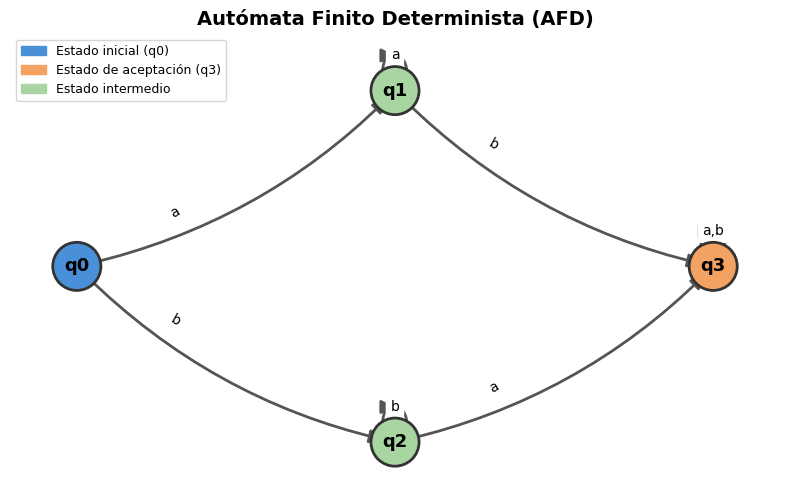

Diagrama guardado.


In [44]:
fig, ax = plt.subplots(figsize=(8, 5))

pos = {
    'q0': (0, 0),
    'q1': (2, 1),
    'q2': (2,-1),
    'q3': (4, 0)
}

# Colores: azul=inicial, verde=aceptación, gris=normal
node_colors = {
    'q0': '#4A90D9',   # inicial
    'q1': '#A8D5A2',   # normal
    'q2': '#A8D5A2',   # normal
    'q3': '#F4A261',   # aceptación
}
colors = [node_colors[n] for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=1200, node_color=colors,
                       edgecolors='#333', linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=13, font_weight='bold', ax=ax)

# Aristas con flechas curvas para los lazos
nx.draw_networkx_edges(
    G, pos,
    connectionstyle='arc3,rad=0.15',
    arrowsize=20, arrowstyle='-|>',
    edge_color='#555', width=2, ax=ax
)

# Etiquetas de las aristas
edge_labels = {(u, v): d['label'] for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_size=10, label_pos=0.3, ax=ax)

# Leyenda
patches = [
    mpatches.Patch(color='#4A90D9', label='Estado inicial (q0)'),
    mpatches.Patch(color='#F4A261', label='Estado de aceptación (q3)'),
    mpatches.Patch(color='#A8D5A2', label='Estado intermedio'),
]
ax.legend(handles=patches, loc='upper left', fontsize=9)
ax.set_title("Autómata Finito Determinista (AFD)", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('/tmp/automata.png', dpi=150, bbox_inches='tight')
plt.show()
print("Diagrama guardado.")


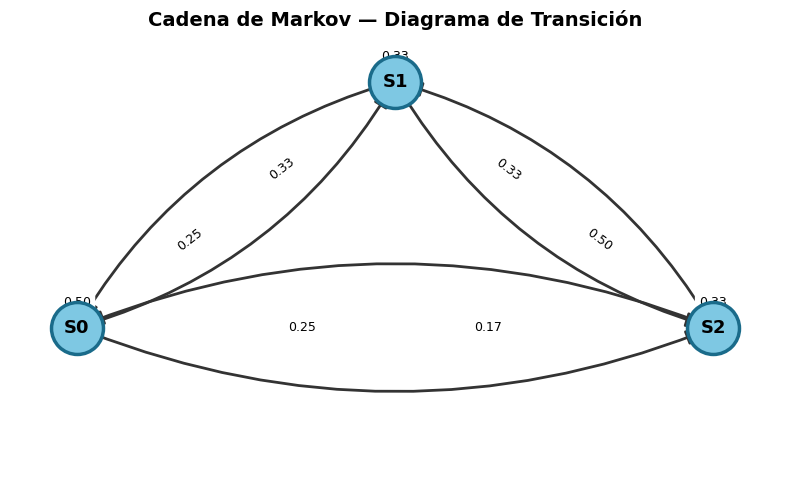

Diagrama guardado.


In [45]:
estados = ['S0', 'S1', 'S2']
M = nx.DiGraph()
M.add_nodes_from(estados)

# Extraer probabilidades de transición de P
probs = [[float(P[i,j].evalf()) for j in range(3)] for i in range(3)]
for i, src in enumerate(estados):
    for j, dst in enumerate(estados):
        w = probs[i][j]
        if w > 0:
            M.add_edge(src, dst, weight=w)

pos_m = {'S0': (0,0), 'S1': (2,1.2), 'S2': (4,0)}

fig, ax = plt.subplots(figsize=(8, 5))

nx.draw_networkx_nodes(M, pos_m, node_size=1400,
                       node_color='#7EC8E3', edgecolors='#1a6b8a',
                       linewidths=2.5, ax=ax)
nx.draw_networkx_labels(M, pos_m, font_size=13, font_weight='bold', ax=ax)
nx.draw_networkx_edges(
    M, pos_m,
    connectionstyle='arc3,rad=0.2',
    arrowsize=22, arrowstyle='-|>',
    edge_color='#333', width=2, ax=ax
)

edge_w = {(u, v): f"{d['weight']:.2f}"
          for u, v, d in M.edges(data=True)}
nx.draw_networkx_edge_labels(M, pos_m, edge_labels=edge_w,
                              font_size=9, label_pos=0.35, ax=ax)

ax.set_title("Cadena de Markov — Diagrama de Transición", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('/tmp/markov.png', dpi=150, bbox_inches='tight')
plt.show()
print("Diagrama guardado.")


In [46]:
print("Propiedades del grafo del autómata ")
print(f"  Número de nodos    : {G.number_of_nodes()}")
print(f"  Número de aristas  : {G.number_of_edges()}")

print("\n  Grado de entrada por nodo:")
for node, deg in G.in_degree():
    print(f"    {node}: {deg}")

print("\n  Grado de salida por nodo:")
for node, deg in G.out_degree():
    print(f"    {node}: {deg}")

print("\nCiclos en el autómata ")
ciclos = list(nx.simple_cycles(G))
for c in ciclos:
    print(f"  {' → '.join(c)} → {c[0]}")


Propiedades del grafo del autómata 
  Número de nodos    : 4
  Número de aristas  : 7

  Grado de entrada por nodo:
    q0: 0
    q1: 2
    q2: 2
    q3: 3

  Grado de salida por nodo:
    q0: 2
    q1: 2
    q2: 2
    q3: 1

Ciclos en el autómata 
  q1 → q1
  q2 → q2
  q3 → q3
